In [1]:
import sys
import os
sys.path.append('/app/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.error_report import get_error_from_list
from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, ErrorEnum, FilterEnum, NoiseTypeEnum
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter


%matplotlib inline
np.random.seed(777)

# Load raw data 0033 (sequence number 09)

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


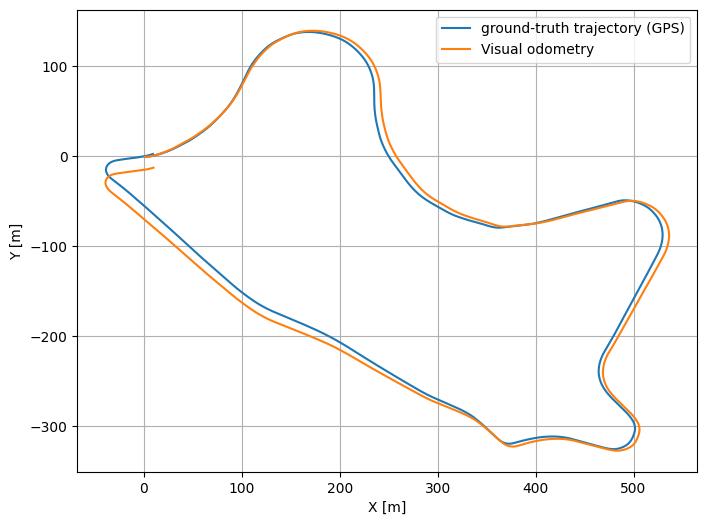

In [2]:
root_path = "../../../"
file_export_path = os.path.join(root_path, "exports/_sequences/09")
kitti_root_dir = os.path.join(root_path, "data")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")
kitti_date = '2011_09_30'
kitti_drive = '0033'
noise_type = NoiseTypeEnum.CURRENT

data = DataLoader(sequence_nr=kitti_drive, 
                  kitti_root_dir=kitti_root_dir, 
                  noise_vector_dir=noise_vector_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0)

## Display data with noise

### VO trajectory with noise

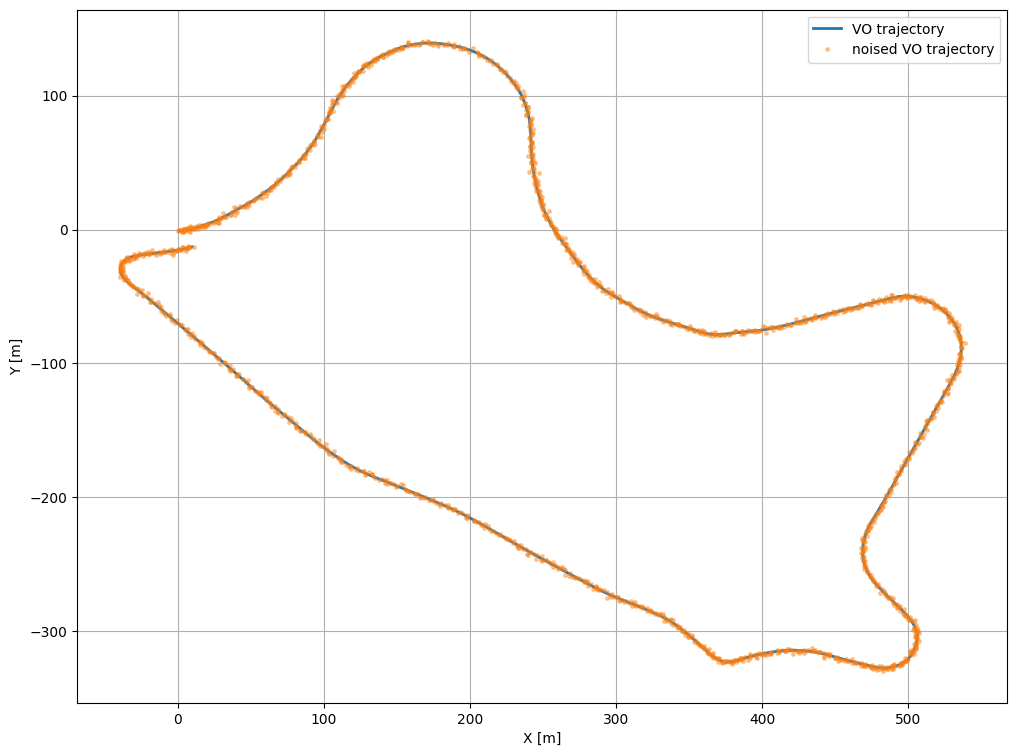

In [3]:
data.show_vo_with_noise()

### Linear acceleration with noise

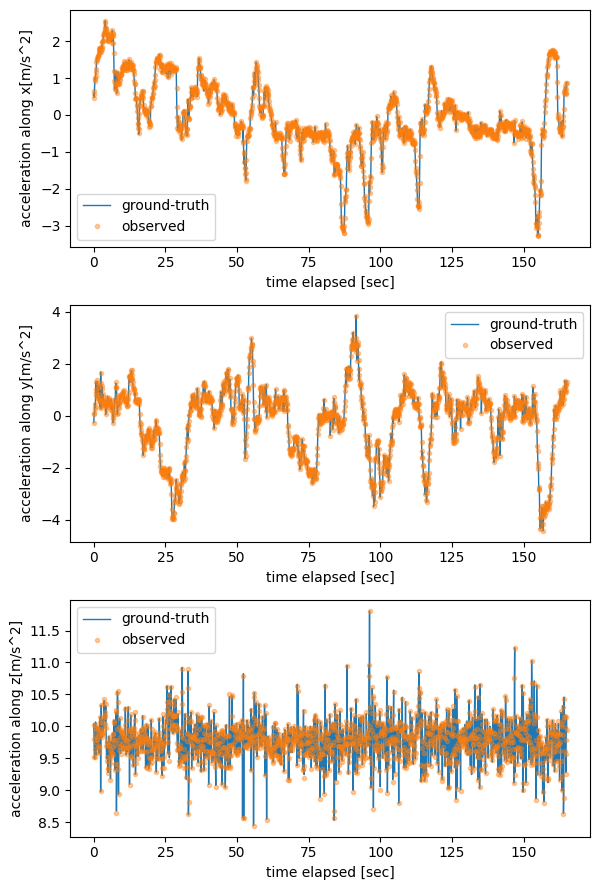

In [4]:
data.show_linear_acceleration_with_noise()

### Angular velocity with noise

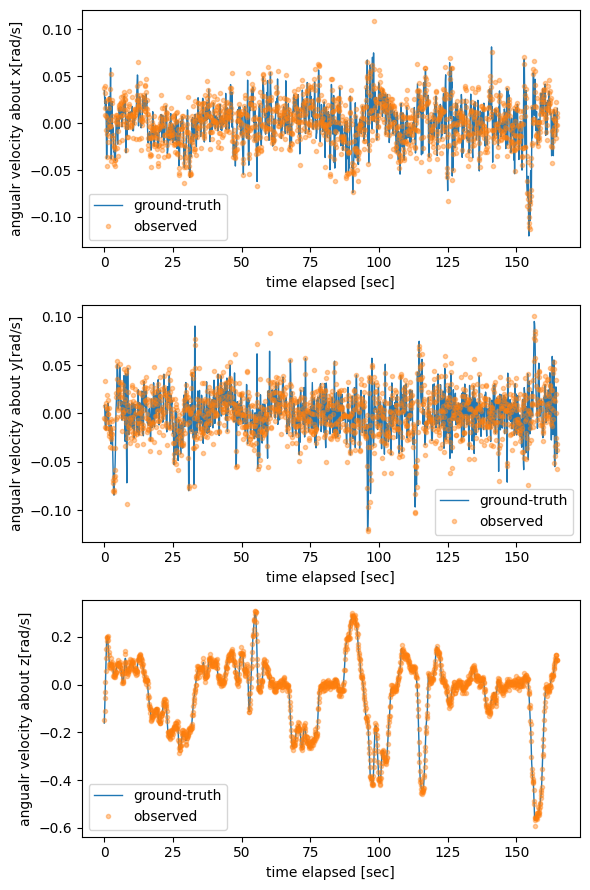

In [5]:
data.show_angular_velocity_with_noise()

### Linear velocity with noise

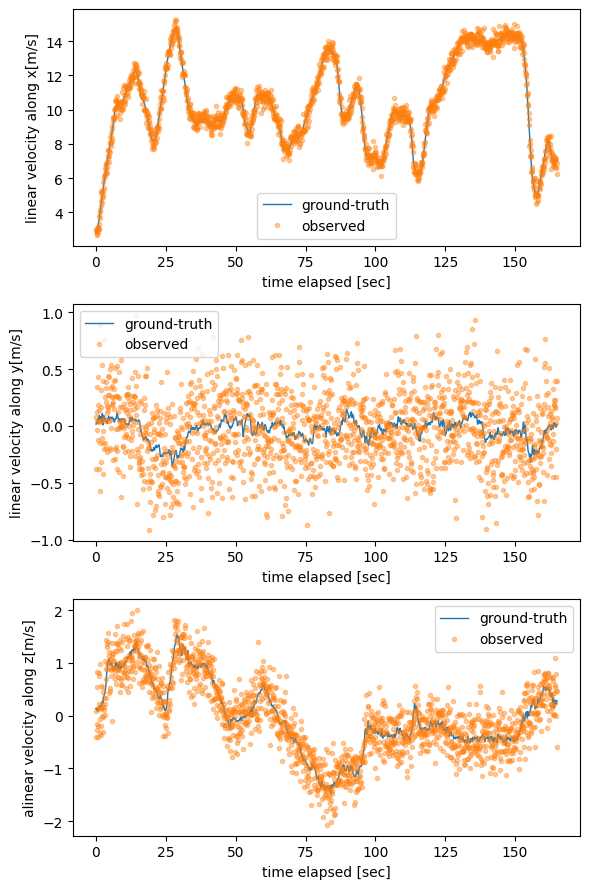

In [6]:
data.show_linear_velocity_with_noise()

# Applying filters

----

In [7]:
results_header = pd.MultiIndex.from_product([['Setup1 (IMU, VO)','Setup2(IMU, VO+GPS)', 'Setup3(INS, VO+INS)'],
                                             ['EKF', 'UKF', 'PF', 'EnKF', 'CKF']],
                                            names=['Setups','Filter types'])
df_dropout_indices = ['No dropout', '10% drop', '20% drop', '30% drop', '40% drop']

def get_error_dataframe(error_0, error_10, error_20, error_30, error_40):
    mae_0 = get_error_from_list(error_0, e_type=ErrorEnum.MAE)
    mae_10 = get_error_from_list(error_10, e_type=ErrorEnum.MAE)
    mae_20 = get_error_from_list(error_20, e_type=ErrorEnum.MAE)
    mae_30 = get_error_from_list(error_30, e_type=ErrorEnum.MAE)
    mae_40 = get_error_from_list(error_40, e_type=ErrorEnum.MAE)

    rmse_0 = get_error_from_list(error_0, e_type=ErrorEnum.RMSE)
    rmse_10 = get_error_from_list(error_10, e_type=ErrorEnum.RMSE)
    rmse_20 = get_error_from_list(error_20, e_type=ErrorEnum.RMSE)
    rmse_30 = get_error_from_list(error_30, e_type=ErrorEnum.RMSE)
    rmse_40 = get_error_from_list(error_40, e_type=ErrorEnum.RMSE)
    
    max_0 = get_error_from_list(error_0, e_type=ErrorEnum.MAX)
    max_10 = get_error_from_list(error_10, e_type=ErrorEnum.MAX)
    max_20 = get_error_from_list(error_20, e_type=ErrorEnum.MAX)
    max_30 = get_error_from_list(error_30, e_type=ErrorEnum.MAX)
    max_40 = get_error_from_list(error_40, e_type=ErrorEnum.MAX)
    
    mae_error = [mae_0, mae_10, mae_20, mae_30, mae_40]
    rmse_error = [rmse_0, rmse_10, rmse_20, rmse_30, rmse_40]
    max_error = [max_0, max_10, max_20, max_30, max_40]
    
    mae_df = pd.DataFrame(np.array(mae_error), 
                            index=df_dropout_indices, 
                            columns=results_header)
    rmse_df = pd.DataFrame(np.array(rmse_error), 
                            index=df_dropout_indices, 
                            columns=results_header)
    max_df = pd.DataFrame(np.array(max_error), 
                            index=df_dropout_indices, 
                            columns=results_header)
    
    return mae_df, rmse_df, max_df



In [8]:
errors_0 = []
errors_10 = []
errors_20 = []
errors_30 = []
errors_40 = []

# No measurement data drop

In [9]:
data.change_dropout_ratio(vo_dropout_ratio=0.0, gps_dropout_ratio=0.0)

In [10]:
alpha_setup1_0 = 1.0
beta_setup1_0 = 2.0
kappa_setup1_0 = 0.0

alpha_setup2_0 = 1.0
beta_setup2_0 = 2.0
kappa_setup2_0 = 0.0

alpha_setup3_0 = 0.001
beta_setup3_0 = 2.0
kappa_setup3_0 = 0.0

n_samples_setup1_0 = 512
resampling_algorithm_setup1_0 = ResamplingAlgorithms.STRATIFIED
n_samples_setup2_0 = 512
resampling_algorithm_setup2_0 = ResamplingAlgorithms.MULTINOMIAL
n_samples_setup3_0 = 64
resampling_algorithm_setup3_0 = ResamplingAlgorithms.RESIDUAL
importance_resampling = True

n_ensemble_setup1_0 = 32
n_ensemble_setup2_0 = 2048
n_ensemble_setup3_0 = 1024

## Setup1

In [11]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_0 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_0 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_0, 
  beta=beta_setup1_0, 
  kappa=kappa_setup1_0,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_0 = ParticleFilter(
  N=n_samples_setup1_0, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_0
)
pf1_0.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_0, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_0 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [12]:
error_ekf1_0 = ekf1_0.run(data=data, debug_mode=True)
error_ukf1_0 = ukf1_0.run(data=data, debug_mode=True)
error_pf1_0 = pf1_0.run(data=data, debug_mode=True, importance_resampling=importance_resampling)
error_enkf1_0 = enkf1_0.run(data=data, debug_mode=True)
error_ckf1_0 = ckf1_0.run(data=data, debug_mode=True)


errors_0.append(error_ekf1_0)
errors_0.append(error_ukf1_0)
errors_0.append(error_pf1_0)
errors_0.append(error_enkf1_0)
errors_0.append(error_ckf1_0)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 12067.10it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.904 m
Root Mean Squared Error: 5.486 m
Maximum Error: 16.056 m
---------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2628.30it/s]



----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.17 m
Root Mean Squared Error: 5.682 m
Maximum Error: 16.566 m
---------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 98.663 m
Root Mean Squared Error: 189.887 m
Maximum Error: 887.81 m
--------------------------------------------------

[EnKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2062.23it/s]



----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.071 m
Root Mean Squared Error: 5.632 m
Maximum Error: 18.276 m
----------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2733.11it/s]


----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.955 m
Root Mean Squared Error: 5.522 m
Maximum Error: 16.221 m
---------------------------------------------------



## Setup2

In [13]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_0 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_0 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_0, 
    beta=beta_setup2_0, 
    kappa=kappa_setup2_0,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_0 = ParticleFilter(
  N=n_samples_setup2_0, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_0
)
pf2_0.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_0, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_0 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [14]:
error_ekf2_0 = ekf2_0.run(data=data, debug_mode=True)
error_ukf2_0 = ukf2_0.run(data=data, debug_mode=True)
error_pf2_0 = pf2_0.run(data=data, debug_mode=True, importance_resampling=importance_resampling)
error_enkf2_0 = enkf2_0.run(data=data, debug_mode=True)
error_ckf2_0 = ckf2_0.run(data=data, debug_mode=True)

errors_0.append(error_ekf2_0)
errors_0.append(error_ukf2_0)
errors_0.append(error_pf2_0)
errors_0.append(error_enkf2_0)
errors_0.append(error_ckf2_0)

[EKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 9973.42it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.99 m
Root Mean Squared Error: 2.762 m
Maximum Error: 8.483 m
-------------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2004.89it/s]



----- [UKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.509 m
Root Mean Squared Error: 2.01 m
Maximum Error: 6.659 m
-------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 11.077 m
Root Mean Squared Error: 51.837 m
Maximum Error: 444.449 m
------------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:53<00:00, 29.97it/s]



----- [EnKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.071 m
Root Mean Squared Error: 1.34 m
Maximum Error: 5.055 m
--------------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2077.50it/s]


----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.462 m
Root Mean Squared Error: 1.967 m
Maximum Error: 6.375 m
-------------------------------------------------------



## Setup3

In [15]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_0 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_0 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_0, 
  beta=beta_setup3_0, 
  kappa=kappa_setup3_0,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_0 = ParticleFilter(
  N=n_samples_setup3_0, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_0
)
pf3_0.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_0, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_0 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [16]:
error_ekf3_0 = ekf3_0.run(data=data, debug_mode=True)
error_ukf3_0 = ukf3_0.run(data=data, debug_mode=True)
error_pf3_0 = pf3_0.run(data=data, debug_mode=True, importance_resampling=importance_resampling)
error_enkf3_0 = enkf3_0.run(data=data, debug_mode=True)
error_ckf3_0 = ckf3_0.run(data=data, debug_mode=True)

errors_0.append(error_ekf3_0)
errors_0.append(error_ukf3_0)
errors_0.append(error_pf3_0)
errors_0.append(error_enkf3_0)
errors_0.append(error_ckf3_0)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 19705.24it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.948 m
Root Mean Squared Error: 2.737 m
Maximum Error: 8.202 m
-----------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6469.83it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.549 m
Root Mean Squared Error: 2.098 m
Maximum Error: 6.744 m
-----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.53 m
Root Mean Squared Error: 0.682 m
Maximum Error: 2.628 m
----------------------------------------------

[EnKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:12<00:00, 128.36it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.965 m
Root Mean Squared Error: 1.219 m
Maximum Error: 6.031 m
------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6809.43it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.55 m
Root Mean Squared Error: 2.099 m
Maximum Error: 6.745 m
-----------------------------------------------



# 10% drop

In [17]:
data.change_dropout_ratio(vo_dropout_ratio=0.1, gps_dropout_ratio=0.1)

In [18]:
alpha_setup1_10 = 1.0
beta_setup1_10 = 2.0
kappa_setup1_10 = 0.0

alpha_setup2_10 = 1.0
beta_setup2_10 = 2.0
kappa_setup2_10 = 0.0

alpha_setup3_10 = 0.001
beta_setup3_10 = 2.0
kappa_setup3_10 = 0.0

n_samples_setup1_10 = 512
resampling_algorithm_setup1_10 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_10 = 512
resampling_algorithm_setup2_10 = ResamplingAlgorithms.MULTINOMIAL
n_samples_setup3_10 = 256
resampling_algorithm_setup3_10 = ResamplingAlgorithms.STRATIFIED

n_ensemble_setup1_10 = 64
n_ensemble_setup2_10 = 1024
n_ensemble_setup3_10 = 256

## Setup1

In [19]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_10 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_10 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_10, 
  beta=beta_setup1_10, 
  kappa=kappa_setup1_10,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_10 = ParticleFilter(
  N=n_samples_setup1_10, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_10
)
pf1_10.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_10 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_10, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_10 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [20]:
error_ekf1_10 = ekf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_10 = ukf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_10 = pf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf1_10 = enkf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_10 = ckf1_10.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)

errors_10.append(error_ekf1_10)
errors_10.append(error_ukf1_10)
errors_10.append(error_pf1_10)
errors_10.append(error_enkf1_10)
errors_10.append(error_ckf1_10)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 10900.42it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.901 m
Root Mean Squared Error: 5.48 m
Maximum Error: 16.047 m
---------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2550.66it/s]



----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.353 m
Root Mean Squared Error: 6.026 m
Maximum Error: 20.145 m
---------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.92 m
Root Mean Squared Error: 5.475 m
Maximum Error: 16.203 m
--------------------------------------------------

[EnKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 1168.44it/s]



----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.066 m
Root Mean Squared Error: 5.603 m
Maximum Error: 17.297 m
----------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2669.49it/s]


----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.809 m
Root Mean Squared Error: 5.356 m
Maximum Error: 15.592 m
---------------------------------------------------



## Setup2

In [21]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_10 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_10 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_10, 
    beta=beta_setup2_10, 
    kappa=kappa_setup2_10,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_10 = ParticleFilter(
  N=n_samples_setup2_10, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_10
)
pf2_10.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_10 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_10, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_10 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [22]:
error_ekf2_10 = ekf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_10 = ukf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_10 = pf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf2_10 = enkf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_10 = ckf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_10.append(error_ekf2_10)
errors_10.append(error_ukf2_10)
errors_10.append(error_pf2_10)
errors_10.append(error_enkf2_10)
errors_10.append(error_ckf2_10)

[EKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 9355.64it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.987 m
Root Mean Squared Error: 2.796 m
Maximum Error: 12.658 m
-------------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 1927.80it/s]



----- [UKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.614 m
Root Mean Squared Error: 2.294 m
Maximum Error: 15.511 m
-------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.716 m
Root Mean Squared Error: 1.003 m
Maximum Error: 9.09 m
------------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:24<00:00, 65.95it/s]



----- [EnKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.43 m
Root Mean Squared Error: 2.325 m
Maximum Error: 18.936 m
--------------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2179.13it/s]


----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.554 m
Root Mean Squared Error: 2.224 m
Maximum Error: 15.337 m
-------------------------------------------------------



## Setup3

In [23]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_10 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_10 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_10, 
  beta=beta_setup3_10, 
  kappa=kappa_setup3_10,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_10 = ParticleFilter(
  N=n_samples_setup3_10, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_10
)
pf3_10.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_10 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_10, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_10 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [24]:
error_ekf3_10 = ekf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_10 = ukf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_10 = pf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf3_10 = enkf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_10 = ckf3_10.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_10.append(error_ekf3_10)
errors_10.append(error_ukf3_10)
errors_10.append(error_pf3_10)
errors_10.append(error_enkf3_10)
errors_10.append(error_ckf3_10)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 17361.66it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.951 m
Root Mean Squared Error: 2.75 m
Maximum Error: 11.923 m
-----------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6119.43it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.602 m
Root Mean Squared Error: 2.25 m
Maximum Error: 14.289 m
-----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.524 m
Root Mean Squared Error: 0.759 m
Maximum Error: 6.966 m
----------------------------------------------

[EnKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:03<00:00, 515.11it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.337 m
Root Mean Squared Error: 2.148 m
Maximum Error: 16.726 m
------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6892.32it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.602 m
Root Mean Squared Error: 2.251 m
Maximum Error: 14.29 m
-----------------------------------------------



# 20% drop

In [25]:
data.change_dropout_ratio(vo_dropout_ratio=0.2, gps_dropout_ratio=0.2)

In [26]:
alpha_setup1_20 = 1.0
beta_setup1_20 = 2.0
kappa_setup1_20 = 0.0

alpha_setup2_20 = 1.0
beta_setup2_20 = 2.0
kappa_setup2_20 = 0.0

alpha_setup3_20 = 0.001
beta_setup3_20 = 2.0
kappa_setup3_20 = 0.0

n_samples_setup1_20 = 512
resampling_algorithm_setup1_20 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_20 = 512
resampling_algorithm_setup2_20 = ResamplingAlgorithms.STRATIFIED
n_samples_setup3_20 = 128
resampling_algorithm_setup3_20 = ResamplingAlgorithms.MULTINOMIAL

n_ensemble_setup1_20 = 64
n_ensemble_setup2_20 = 1024
n_ensemble_setup3_20 = 512

## Setup1

In [27]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_20 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_20 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_20, 
  beta=beta_setup1_20, 
  kappa=kappa_setup1_20,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_20 = ParticleFilter(
  N=n_samples_setup1_20, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_20
)
pf1_20.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_20 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_20, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_20 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [28]:
error_ekf1_20 = ekf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_20 = ukf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_20 = pf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf1_20 = enkf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_20 = ckf1_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)

errors_20.append(error_ekf1_20)
errors_20.append(error_ukf1_20)
errors_20.append(error_pf1_20)
errors_20.append(error_enkf1_20)
errors_20.append(error_ckf1_20)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 11891.25it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.93 m
Root Mean Squared Error: 5.512 m
Maximum Error: 16.59 m
---------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2688.26it/s]



----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.468 m
Root Mean Squared Error: 5.79 m
Maximum Error: 19.481 m
---------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.947 m
Root Mean Squared Error: 5.53 m
Maximum Error: 17.103 m
--------------------------------------------------

[EnKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 1202.67it/s]



----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.094 m
Root Mean Squared Error: 5.617 m
Maximum Error: 19.21 m
----------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2852.02it/s]


----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.913 m
Root Mean Squared Error: 5.53 m
Maximum Error: 16.624 m
---------------------------------------------------



## Setup2

In [29]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_20 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_20 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_20, 
    beta=beta_setup2_20, 
    kappa=kappa_setup2_20,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_20 = ParticleFilter(
  N=n_samples_setup2_20, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_20
)
pf2_20.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_20 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_20, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_20 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [30]:
error_ekf2_20 = ekf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_20 = ukf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_20 = pf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf2_20 = enkf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_20 = ckf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_20.append(error_ekf2_20)
errors_20.append(error_ukf2_20)
errors_20.append(error_pf2_20)
errors_20.append(error_enkf2_20)
errors_20.append(error_ckf2_20)

[EKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 9710.65it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.988 m
Root Mean Squared Error: 2.828 m
Maximum Error: 13.364 m
-------------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2171.72it/s]



----- [UKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.71 m
Root Mean Squared Error: 2.508 m
Maximum Error: 15.663 m
-------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 232.381 m
Root Mean Squared Error: 517.365 m
Maximum Error: 2067.478 m
------------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:22<00:00, 70.05it/s]



----- [EnKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.693 m
Root Mean Squared Error: 2.909 m
Maximum Error: 20.486 m
--------------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2263.85it/s]


----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.634 m
Root Mean Squared Error: 2.435 m
Maximum Error: 15.354 m
-------------------------------------------------------



## Setup3

In [31]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_20 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_20 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_20, 
  beta=beta_setup3_20, 
  kappa=kappa_setup3_20,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_20 = ParticleFilter(
  N=n_samples_setup3_20, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_20
)
pf3_20.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_20 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_20, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_20 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [32]:
error_ekf3_20 = ekf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_20 = ukf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_20 = pf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf3_20 = enkf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_20 = ckf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_20.append(error_ekf3_20)
errors_20.append(error_ukf3_20)
errors_20.append(error_pf3_20)
errors_20.append(error_enkf3_20)
errors_20.append(error_ckf3_20)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 19066.22it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.958 m
Root Mean Squared Error: 2.77 m
Maximum Error: 12.329 m
-----------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 7215.82it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.658 m
Root Mean Squared Error: 2.386 m
Maximum Error: 14.058 m
-----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.633 m
Root Mean Squared Error: 0.954 m
Maximum Error: 12.275 m
----------------------------------------------

[EnKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:05<00:00, 307.25it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.588 m
Root Mean Squared Error: 2.632 m
Maximum Error: 17.947 m
------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 7508.97it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.658 m
Root Mean Squared Error: 2.387 m
Maximum Error: 14.058 m
-----------------------------------------------



# 30% drop

In [33]:
data.change_dropout_ratio(vo_dropout_ratio=0.3, gps_dropout_ratio=0.3)

In [34]:
alpha_setup1_30 = 0.0001
beta_setup1_30 = 2.0
kappa_setup1_30 = 0.0

alpha_setup2_30 = 1.0
beta_setup2_30 = 2.0
kappa_setup2_30 = 0.0

alpha_setup3_30 = 0.001
beta_setup3_30 = 2.0
kappa_setup3_30 = 0.0

n_samples_setup1_30 = 512
resampling_algorithm_setup1_30 = ResamplingAlgorithms.MULTINOMIAL
n_samples_setup2_30 = 512
resampling_algorithm_setup2_30 = ResamplingAlgorithms.RESIDUAL
n_samples_setup3_30 = 64
resampling_algorithm_setup3_30 = ResamplingAlgorithms.RESIDUAL

n_ensemble_setup1_30 = 128
n_ensemble_setup2_30 = 1024
n_ensemble_setup3_30 = 64

## Setup1

In [35]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_30 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_30 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_30, 
  beta=beta_setup1_30, 
  kappa=kappa_setup1_30,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_30 = ParticleFilter(
  N=n_samples_setup1_30, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_30
)
pf1_30.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_30 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_30, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_30 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 12171.96it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.944 m
Root Mean Squared Error: 5.509 m
Maximum Error: 16.642 m
---------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2842.34it/s]



----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 143.279 m
Root Mean Squared Error: 2109.864 m
Maximum Error: 61439.787 m
---------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.949 m
Root Mean Squared Error: 5.527 m
Maximum Error: 16.98 m
--------------------------------------------------

[EnKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 673.18it/s]



----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.14 m
Root Mean Squared Error: 5.678 m
Maximum Error: 19.028 m
----------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2954.99it/s]



----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.304 m
Root Mean Squared Error: 5.875 m
Maximum Error: 17.278 m
---------------------------------------------------



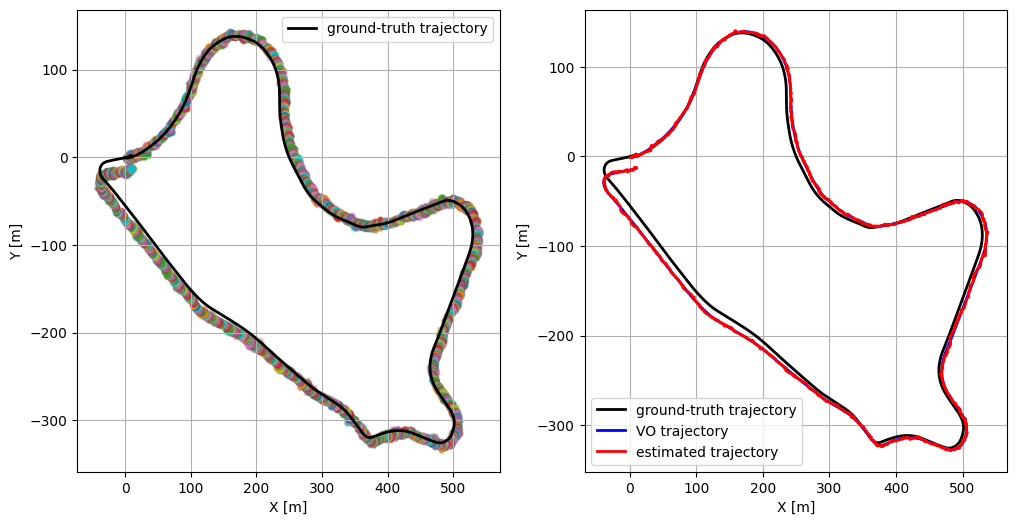

In [36]:
error_ekf1_30 = ekf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_30 = ukf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_30 = pf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True,
    show_graph=True
)
error_enkf1_30 = enkf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_30 = ckf1_30.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_30.append(error_ekf1_30)
errors_30.append(error_ukf1_30)
errors_30.append(error_pf1_30)
errors_30.append(error_enkf1_30)
errors_30.append(error_ckf1_30)

## Setup2

In [37]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_30 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_30 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_30, 
    beta=beta_setup2_30, 
    kappa=kappa_setup2_30,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_30 = ParticleFilter(
  N=n_samples_setup2_30, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_30
)
pf2_30.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_30 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_30, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_30 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [38]:
error_ekf2_30 = ekf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_30 = ukf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_30 = pf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf2_30 = enkf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_30 = ckf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_30.append(error_ekf2_30)
errors_30.append(error_ukf2_30)
errors_30.append(error_pf2_30)
errors_30.append(error_enkf2_30)
errors_30.append(error_ckf2_30)

[EKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 8993.48it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 2.034 m
Root Mean Squared Error: 2.908 m
Maximum Error: 13.008 m
-------------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2259.83it/s]



----- [UKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.892 m
Root Mean Squared Error: 2.712 m
Maximum Error: 14.652 m
-------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 215.692 m
Root Mean Squared Error: 494.461 m
Maximum Error: 2310.696 m
------------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:21<00:00, 73.32it/s]



----- [EnKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 2.019 m
Root Mean Squared Error: 3.426 m
Maximum Error: 24.301 m
--------------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2208.92it/s]


----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.754 m
Root Mean Squared Error: 2.612 m
Maximum Error: 14.733 m
-------------------------------------------------------



## Setup3

In [39]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_30 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_30 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_30, 
  beta=beta_setup3_30, 
  kappa=kappa_setup3_30,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_30 = ParticleFilter(
  N=n_samples_setup3_30, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_30
)
pf3_30.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_30 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_30, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_30 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [40]:
error_ekf3_30 = ekf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_30 = ukf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_30 = pf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf3_30 = enkf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_30 = ckf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)


errors_30.append(error_ekf3_30)
errors_30.append(error_ukf3_30)
errors_30.append(error_pf3_30)
errors_30.append(error_enkf3_30)
errors_30.append(error_ckf3_30)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 19644.12it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.985 m
Root Mean Squared Error: 2.796 m
Maximum Error: 11.683 m
-----------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 7675.83it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.734 m
Root Mean Squared Error: 2.5 m
Maximum Error: 13.451 m
-----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.702 m
Root Mean Squared Error: 1.027 m
Maximum Error: 7.198 m
----------------------------------------------

[EnKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2150.61it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.879 m
Root Mean Squared Error: 3.096 m
Maximum Error: 19.081 m
------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 7954.49it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.735 m
Root Mean Squared Error: 2.5 m
Maximum Error: 13.455 m
-----------------------------------------------



# 40% drop

In [41]:
data.change_dropout_ratio(vo_dropout_ratio=0.4, gps_dropout_ratio=0.4)

In [42]:
alpha_setup1_40 = 0.1000
beta_setup1_40 = 2.0
kappa_setup1_40 = 0.0

alpha_setup2_40 = 1.
beta_setup2_40 = 2.0
kappa_setup2_40 = 0.0

alpha_setup3_40 = 0.001
beta_setup3_40 = 2.0
kappa_setup3_40 = 0.0

n_samples_setup1_40 = 512
resampling_algorithm_setup1_40 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_40 = 512
resampling_algorithm_setup2_40 = ResamplingAlgorithms.STRATIFIED
n_samples_setup3_40 = 64
resampling_algorithm_setup3_40 = ResamplingAlgorithms.STRATIFIED

n_ensemble_setup1_40 = 32
n_ensemble_setup2_40 = 1024
n_ensemble_setup3_40 = 64

## Setup1

In [43]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_40 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_40 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_40, 
  beta=beta_setup1_40, 
  kappa=kappa_setup1_40,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_40 = ParticleFilter(
  N=n_samples_setup1_40, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_40
)
pf1_40.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_40 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_40, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_40 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [44]:
error_ekf1_40 = ekf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_40 = ukf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_40 = pf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf1_40 = enkf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_40 = ckf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)

errors_40.append(error_ekf1_40)
errors_40.append(error_ukf1_40)
errors_40.append(error_pf1_40)
errors_40.append(error_enkf1_40)
errors_40.append(error_ckf1_40)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 11100.31it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.938 m
Root Mean Squared Error: 5.491 m
Maximum Error: 17.088 m
---------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2894.23it/s]



----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 14.302 m
Root Mean Squared Error: 57.552 m
Maximum Error: 1245.371 m
---------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.945 m
Root Mean Squared Error: 5.487 m
Maximum Error: 17.374 m
--------------------------------------------------

[EnKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2359.03it/s]



----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.133 m
Root Mean Squared Error: 5.63 m
Maximum Error: 21.137 m
----------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 3054.13it/s]


----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.042 m
Root Mean Squared Error: 5.376 m
Maximum Error: 15.088 m
---------------------------------------------------



## Setup2

In [45]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_40 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_40 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_40, 
    beta=beta_setup2_40, 
    kappa=kappa_setup2_40,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_40 = ParticleFilter(
  N=n_samples_setup2_40, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_40
)
pf2_40.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_40 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_40, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_40 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [46]:
error_ekf2_40 = ekf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_40 = ukf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_40 = pf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf2_40 = enkf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_40 = ckf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_40.append(error_ekf2_40)
errors_40.append(error_ukf2_40)
errors_40.append(error_pf2_40)
errors_40.append(error_enkf2_40)
errors_40.append(error_ckf2_40)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 10694.64it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 2.026 m
Root Mean Squared Error: 2.916 m
Maximum Error: 15.933 m
-------------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2414.81it/s]



----- [UKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 2.017 m
Root Mean Squared Error: 2.912 m
Maximum Error: 16.984 m
-------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.112 m
Root Mean Squared Error: 1.693 m
Maximum Error: 12.745 m
------------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:20<00:00, 75.77it/s]



----- [EnKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 2.21 m
Root Mean Squared Error: 3.765 m
Maximum Error: 24.207 m
--------------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2094.60it/s]


----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.772 m
Root Mean Squared Error: 2.685 m
Maximum Error: 18.395 m
-------------------------------------------------------



## Setup3

In [47]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_40 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_40 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_40, 
  beta=beta_setup3_40, 
  kappa=kappa_setup3_40,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_40 = ParticleFilter(
  N=n_samples_setup3_40, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_40
)
pf3_40.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_40 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_40, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_40 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [48]:
error_ekf3_40 = ekf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_40 = ukf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_40 = pf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf3_40 = enkf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_40 = ckf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_40.append(error_ekf3_40)
errors_40.append(error_ukf3_40)
errors_40.append(error_pf3_40)
errors_40.append(error_enkf3_40)
errors_40.append(error_ckf3_40)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 20432.94it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.975 m
Root Mean Squared Error: 2.791 m
Maximum Error: 14.487 m
-----------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 8161.78it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.751 m
Root Mean Squared Error: 2.565 m
Maximum Error: 15.699 m
-----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.755 m
Root Mean Squared Error: 1.175 m
Maximum Error: 8.6 m
----------------------------------------------

[EnKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2466.69it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 2.106 m
Root Mean Squared Error: 3.417 m
Maximum Error: 19.073 m
------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 8784.55it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.752 m
Root Mean Squared Error: 2.566 m
Maximum Error: 15.696 m
-----------------------------------------------



# Results

In [49]:
mae_df, rmse_df, max_df = get_error_dataframe(errors_0, errors_10, errors_20, errors_30, errors_40)

In [50]:
mae_df

Setups       Setup1 (IMU, VO)                                 \
Filter types              EKF      UKF      PF   EnKF    CKF   
No dropout              3.904    4.170  98.663  4.071  3.955   
10% drop                3.901    4.353   3.920  4.066  3.809   
20% drop                3.930    4.468   3.947  4.094  3.913   
30% drop                3.944  143.279   3.949  4.140  4.304   
40% drop                3.938   14.302   3.945  4.133  4.042   

Setups       Setup2(IMU, VO+GPS)                                \
Filter types                 EKF    UKF       PF   EnKF    CKF   
No dropout                 1.990  1.509   11.077  1.071  1.462   
10% drop                   1.987  1.614    0.716  1.430  1.554   
20% drop                   1.988  1.710  232.381  1.693  1.634   
30% drop                   2.034  1.892  215.692  2.019  1.754   
40% drop                   2.026  2.017    1.112  2.210  1.772   

Setups       Setup3(INS, VO+INS)                              
Filter types                 EKF    UKF     PF   EnKF    CKF  
No dropout                 1.948  1.549  0.530  0.965  1.550  
10% drop                   1.951  1.602  0.524  1.337  1.602  
20% drop                   1.958  1.658  0.633  1.588  1.658  
30% drop                   1.985  1.734  0.702  1.879  1.735  
40% drop                   1.975  1.751  0.755  2.106  1.752

In [51]:
rmse_df

Setups       Setup1 (IMU, VO)                                   \
Filter types              EKF       UKF       PF   EnKF    CKF   
No dropout              5.486     5.682  189.887  5.632  5.522   
10% drop                5.480     6.026    5.475  5.603  5.356   
20% drop                5.512     5.790    5.530  5.617  5.530   
30% drop                5.509  2109.864    5.527  5.678  5.875   
40% drop                5.491    57.552    5.487  5.630  5.376   

Setups       Setup2(IMU, VO+GPS)                                \
Filter types                 EKF    UKF       PF   EnKF    CKF   
No dropout                 2.762  2.010   51.837  1.340  1.967   
10% drop                   2.796  2.294    1.003  2.325  2.224   
20% drop                   2.828  2.508  517.365  2.909  2.435   
30% drop                   2.908  2.712  494.461  3.426  2.612   
40% drop                   2.916  2.912    1.693  3.765  2.685   

Setups       Setup3(INS, VO+INS)                              
Filter types                 EKF    UKF     PF   EnKF    CKF  
No dropout                 2.737  2.098  0.682  1.219  2.099  
10% drop                   2.750  2.250  0.759  2.148  2.251  
20% drop                   2.770  2.386  0.954  2.632  2.387  
30% drop                   2.796  2.500  1.027  3.096  2.500  
40% drop                   2.791  2.565  1.175  3.417  2.566

In [52]:
max_df

Setups       Setup1 (IMU, VO)                                      \
Filter types              EKF        UKF       PF    EnKF     CKF   
No dropout             16.056     16.566  887.810  18.276  16.221   
10% drop               16.047     20.145   16.203  17.297  15.592   
20% drop               16.590     19.481   17.103  19.210  16.624   
30% drop               16.642  61439.787   16.980  19.028  17.278   
40% drop               17.088   1245.371   17.374  21.137  15.088   

Setups       Setup2(IMU, VO+GPS)                                    \
Filter types                 EKF     UKF        PF    EnKF     CKF   
No dropout                 8.483   6.659   444.449   5.055   6.375   
10% drop                  12.658  15.511     9.090  18.936  15.337   
20% drop                  13.364  15.663  2067.478  20.486  15.354   
30% drop                  13.008  14.652  2310.696  24.301  14.733   
40% drop                  15.933  16.984    12.745  24.207  18.395   

Setups       Setup3(INS, VO+INS)                                  
Filter types                 EKF     UKF      PF    EnKF     CKF  
No dropout                 8.202   6.744   2.628   6.031   6.745  
10% drop                  11.923  14.289   6.966  16.726  14.290  
20% drop                  12.329  14.058  12.275  17.947  14.058  
30% drop                  11.683  13.451   7.198  19.081  13.455  
40% drop                  14.487  15.699   8.600  19.073  15.696

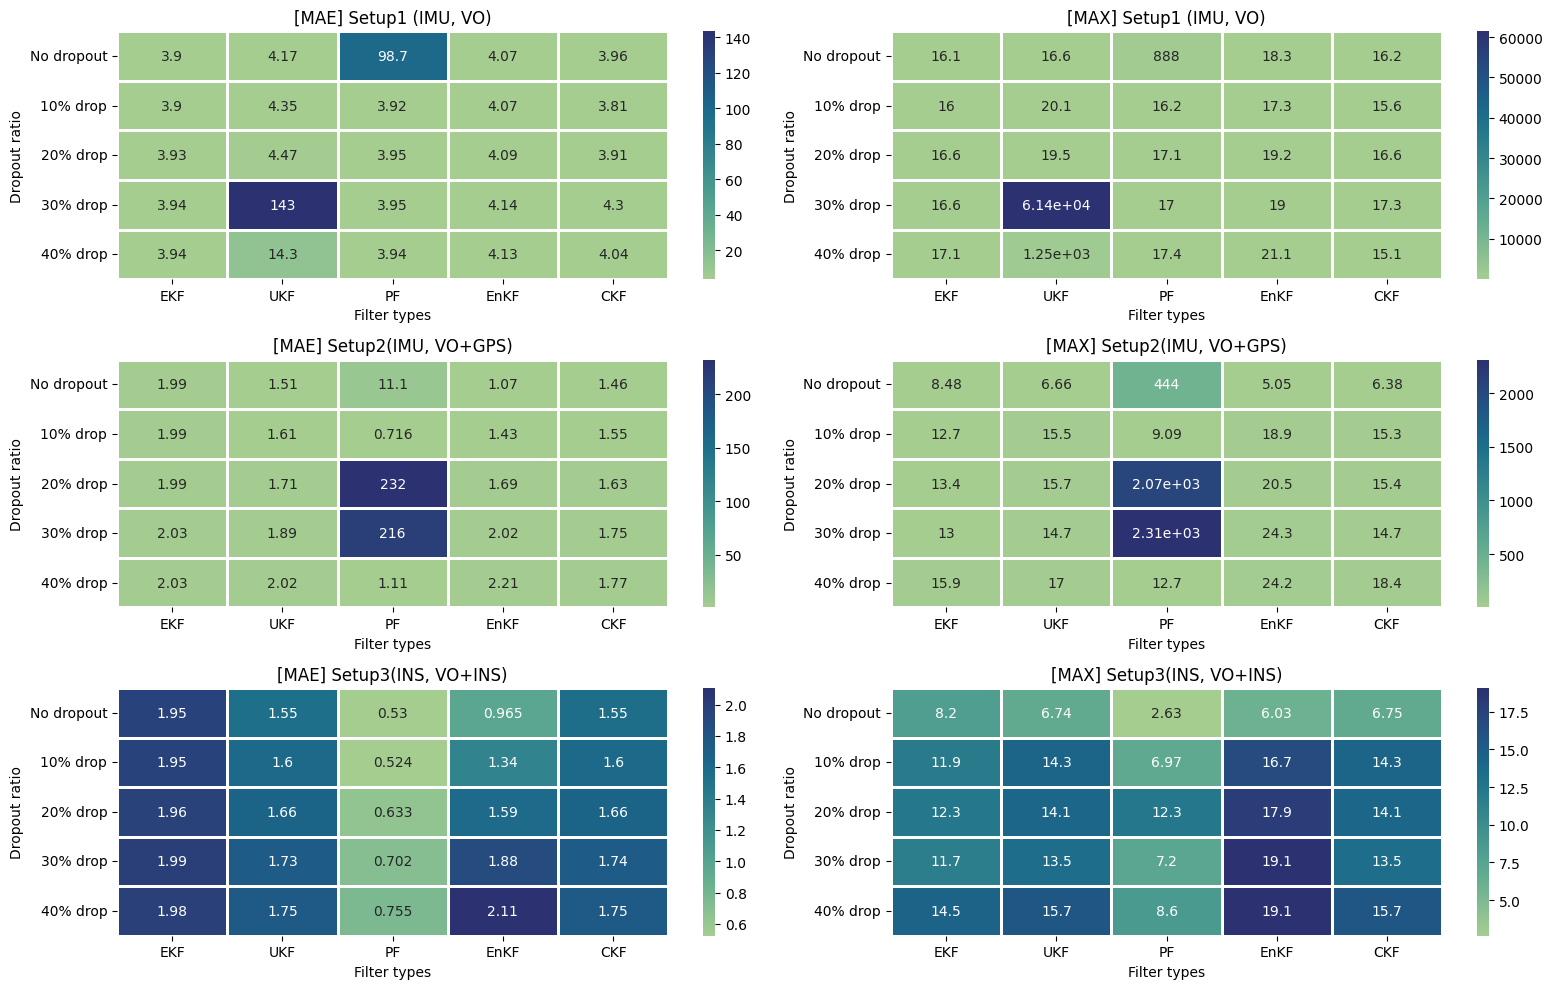

In [53]:
fig, (ax1_, ax2_, ax3_) = plt.subplots(nrows=3, ncols=2, figsize=(16, 10))
ax1, ax2 = ax1_[0], ax1_[1]
ax3, ax4 = ax2_[0], ax2_[1]
ax5, ax6 = ax3_[0], ax3_[1]

sns.heatmap(mae_df["Setup1 (IMU, VO)"],
            ax=ax1,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax1.set_title("[MAE] Setup1 (IMU, VO)")
ax1.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(mae_df["Setup2(IMU, VO+GPS)"],
            ax=ax3,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax3.set_title("[MAE] Setup2(IMU, VO+GPS)")
ax3.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(mae_df["Setup3(INS, VO+INS)"],
            ax=ax5,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax5.set_title("[MAE] Setup3(INS, VO+INS)")
ax5.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(max_df["Setup1 (IMU, VO)"],
            ax=ax2,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax2.set_title("[MAX] Setup1 (IMU, VO)")
ax2.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(max_df["Setup2(IMU, VO+GPS)"],
            ax=ax4,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax4.set_title("[MAX] Setup2(IMU, VO+GPS)")
ax4.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(max_df["Setup3(INS, VO+INS)"],
            ax=ax6,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax6.set_title("[MAX] Setup3(INS, VO+INS)")
ax6.set(xlabel="Filter types", ylabel="Dropout ratio")

fig.tight_layout()

In [54]:
mae_df.to_json(os.path.join(file_export_path, "mae_df.json"))
rmse_df.to_json(os.path.join(file_export_path, "rmse_df.json"))
max_df.to_json(os.path.join(file_export_path, "max_df.json"))

In this notebook, we applied all implemented filters to the KITTI raw data sequence number 09 for each setup.
The parameters for UKF, PF, and EnKF are set according to the result obtained by corresponding parameter tuner notebooks located under `/notebooks/KITTI/experiments/tuning/`.

Although the optimal parameters: size of particles and resampling algorithm, are set to PF, PF experimences filter divergence when 20% and 30% of measurement data is dropped in Setup2.
The same experiment, in which particle size is guarnteed by setting particle size to 2048, is conducted in the `09_pf_guaranteed.ipynb` notebook.